In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter import kalman_filter as kf

# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data

Choose the time interval for which the model is to be run.

In [34]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-03 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.

- **Surface variables** include:
  - Surface air temperature
  - Surface pressure
  - Surface dew point temperature

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [35]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

Storing the time values and the timestep.

In [36]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

Choose how often then Kalman filter is implemented

In [37]:
kalman_hours_1 = 1
kalman_indices_1 = np.mean(np.round(kalman_hours_1*3600/dt_seconds)).astype(int)
kalman_hours_2 = 2
kalman_indices_2 = np.mean(np.round(kalman_hours_2*3600/dt_seconds)).astype(int)
kalman_hours_3 = 3
kalman_indices_3 = np.mean(np.round(kalman_hours_3*3600/dt_seconds)).astype(int)

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [38]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


#### Radiometer LWC 

In [39]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')


#### Environmental profiles and inputs

The model inputs

In [40]:
#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

## Running the model

#### Initializing Model Output Arrays

In [41]:
#state for the model without KF and with 3 different KFs- cloud liquid water
X = np.zeros(len(T_surf))
X_1 = np.zeros(len(T_surf))
X_2 = np.zeros(len(T_surf))
X_3 = np.zeros(len(T_surf))

#precipitation on the ground without KF and with 3 different KFs
P = np.zeros(len(T_surf))
P_1 = np.zeros(len(T_surf))
P_2 = np.zeros(len(T_surf))
P_3 = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))

#updraft velocity
v_updr_arr = np.zeros(len(T_surf))

#liquid water inputs and ``
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_t_arr = np.zeros(len(T_surf))
Q = 0.32

#cloud top pressure and cloud depth
p_t_arr = np.zeros(len(T_surf))
Z_c_arr = np.zeros(len(T_surf))

In [42]:
X[0] = radiometer_lwp[0]   #initial state in kg/m2
X_1[0] = radiometer_lwp[0]   #initial state in kg/m2
X_2[0] = radiometer_lwp[0]  #initial state in kg/m2
X_3[0] = radiometer_lwp[0]   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

Sigma_1 = np.zeros(len(T_surf))
Sigma_1[0] = 1 #initial state covariance in kg/m2
Sigma_2 = np.zeros(len(T_surf))
Sigma_2[0] = 1 #initial state covariance in kg/m2
Sigma_3 = np.zeros(len(T_surf))
Sigma_3[0] = 1 #initial state covariance in kg/m2

#### Model run

In [44]:
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    p_t_arr[i] = p_t
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_updr_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    O_b_arr[i] = O_b*non_dim_numbers(v_updr)[0]/(Z_c)
    O_t_arr[i] = O_t*non_dim_numbers(v_updr)[0]/(Z_c)   
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
    Z_c_arr[i] = Z_c

    #precipitation in kg/m2/s
    #state without Kalman filter
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]
    P_1[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_1[i]
    P_2[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_2[i]
    P_3[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_3[i]

    #state with Kalman filter   
    if i>0:
        
        if i<(len(T_surf)-1):
                X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])
                Sigma[i+1] = Sigma[i] + 2*(h_v*Sigma[i])*dt_seconds[i] + Q*dt_seconds[i]

                X_1[i+1] = X_1[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_1[i])
                Sigma_1[i+1] = Sigma_1[i] + 2*(h_v*Sigma_1[i])*dt_seconds[i] + Q*dt_seconds[i]  

                X_2[i+1] = X_2[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_2[i])
                Sigma_2[i+1] = Sigma_2[i] + 2*(h_v*Sigma_2[i])*dt_seconds[i] + Q*dt_seconds[i]

                X_3[i+1] = X_3[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_3[i])
                Sigma_3[i+1] = Sigma_3[i] + 2*(h_v*Sigma_3[i])*dt_seconds[i] + Q*dt_seconds[i]

                if (((i%kalman_indices_1)==0)&(i>0)):
                    # we assume that we receive a precipitation update every 60mins

                    phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
                    h_kf = h_out(v_updr,Z_c).run()[2]
                    f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
                    
                    kalman_f = kf(X_1[i], Sigma_1[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[i].values) 
                    X_1[i+1],Sigma_1[i+1] = kalman_f.update()    

                if (((i%kalman_indices_2)==0)&(i>0)):
                    # we assume that we receive a precipitation update every 2 hours

                    phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
                    h_kf = h_out(v_updr,Z_c).run()[2]
                    f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
                    
                    kalman_f = kf(X_2[i], Sigma_2[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[i].values) 
                    X_2[i+1],Sigma_2[i+1] = kalman_f.update()

                if (((i%kalman_indices_3)==0)&(i>0)):
                    # we assume that we receive a precipitation update every 3 hours

                    phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
                    h_kf = h_out(v_updr,Z_c).run()[2]
                    f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
                    
                    kalman_f = kf(X_3[i], Sigma_3[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[i].values) 
                    X_3[i+1],Sigma_3[i+1] = kalman_f.update()

## Visualizing the outputs

Text(0, 0.5, 'In cloud Liquid Water Content [g/m3]')

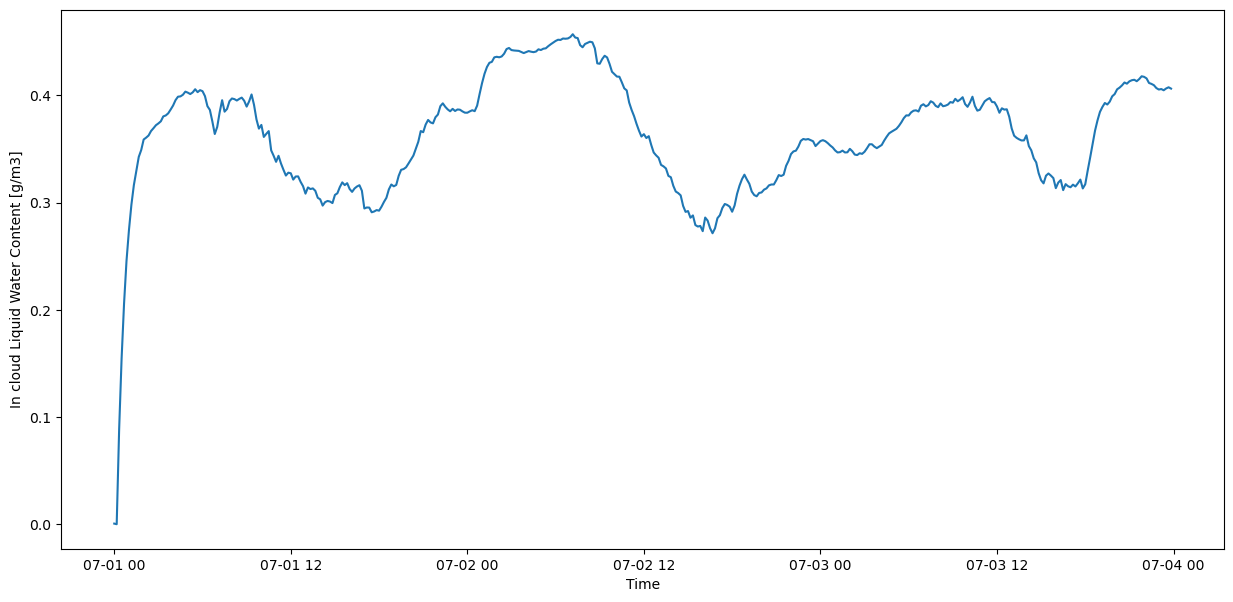

In [45]:
index_rain = np.where((P*3600 > 0.25))[0]
index_no_rain = np.where((rain_rate==0) & (P*3600 < 0.25))[0]
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, X/Z_c_arr*1000)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('In cloud Liquid Water Content [g/m3]')
# Add vertical lines at the corresponding times
#for idx in index_rain:
    #ax.axvline(measurements_used.time[idx].values, color='blue', linestyle='--', alpha=0.3)
#for idx in index_no_rain:
    #ax.axvline(measurements_used.time[idx].values, color='red', linestyle='--', alpha=0.3)



Text(0.5, 0, 'time')

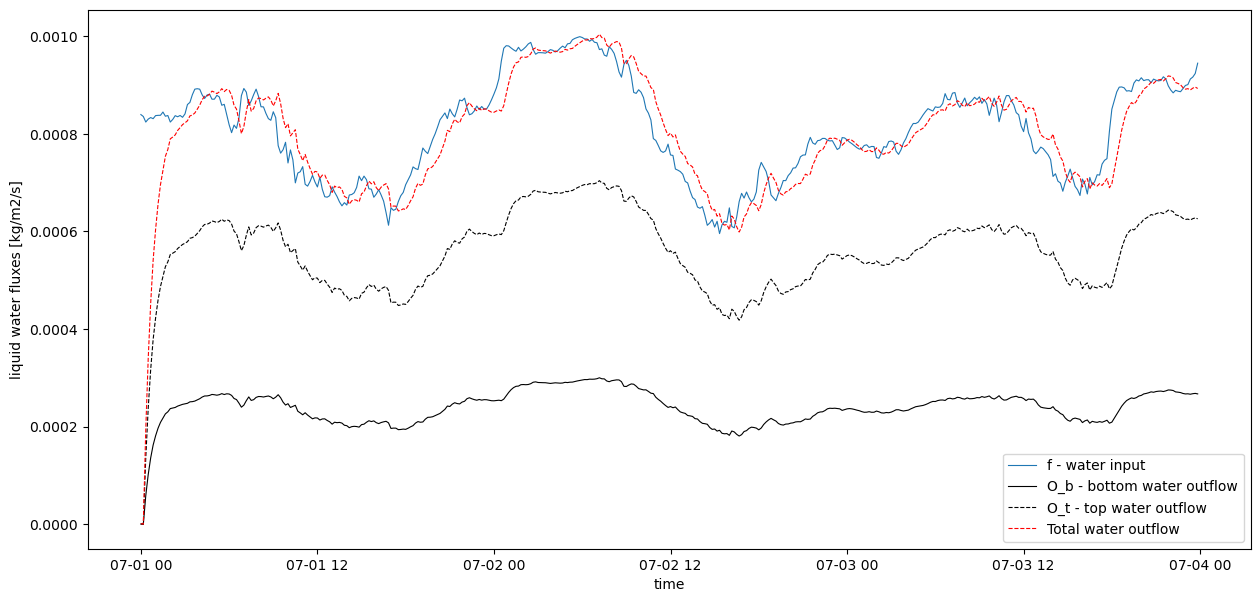

In [46]:
fig, ax = plt.subplots(figsize=(15,7))
plt.plot(measurements_used.time, f_arr,linewidth=0.8,label='f - water input')
plt.plot(measurements_used.time, O_b_arr*X,linewidth=0.8,label='O_b - bottom water outflow',color='black')
plt.plot(measurements_used.time, O_t_arr*X,linewidth=0.8,label='O_t - top water outflow',color='black',linestyle='--')
plt.plot(measurements_used.time, (O_t_arr+O_b_arr)*X,linewidth=0.8,label='Total water outflow',linestyle='--',color='red')
plt.legend()
plt.ylabel('liquid water fluxes [kg/m2/s]')
plt.xlabel('time')

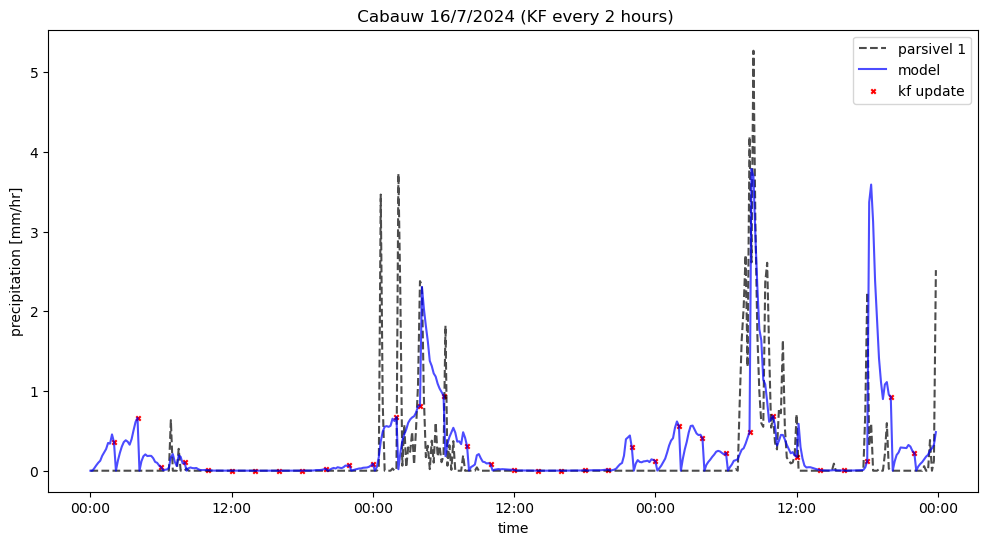

In [47]:
plt.figure(figsize=(12,6))
import matplotlib.dates as mdates

#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(time,rain_rate,label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
#plt.plot(time,P*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
#plt.plot(time,P_1*3600,label='model',color='red',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(time,P_2*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
#plt.plot(time,P_3*3600,label='model',color='green',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.scatter(time[kalman_indices_2::kalman_indices_2],P_2[kalman_indices_2::kalman_indices_2]*3600,label='kf update',marker='x',s=10,color='red')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('time')
plt.title(' Cabauw 16/7/2024 (KF every 2 hours)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()


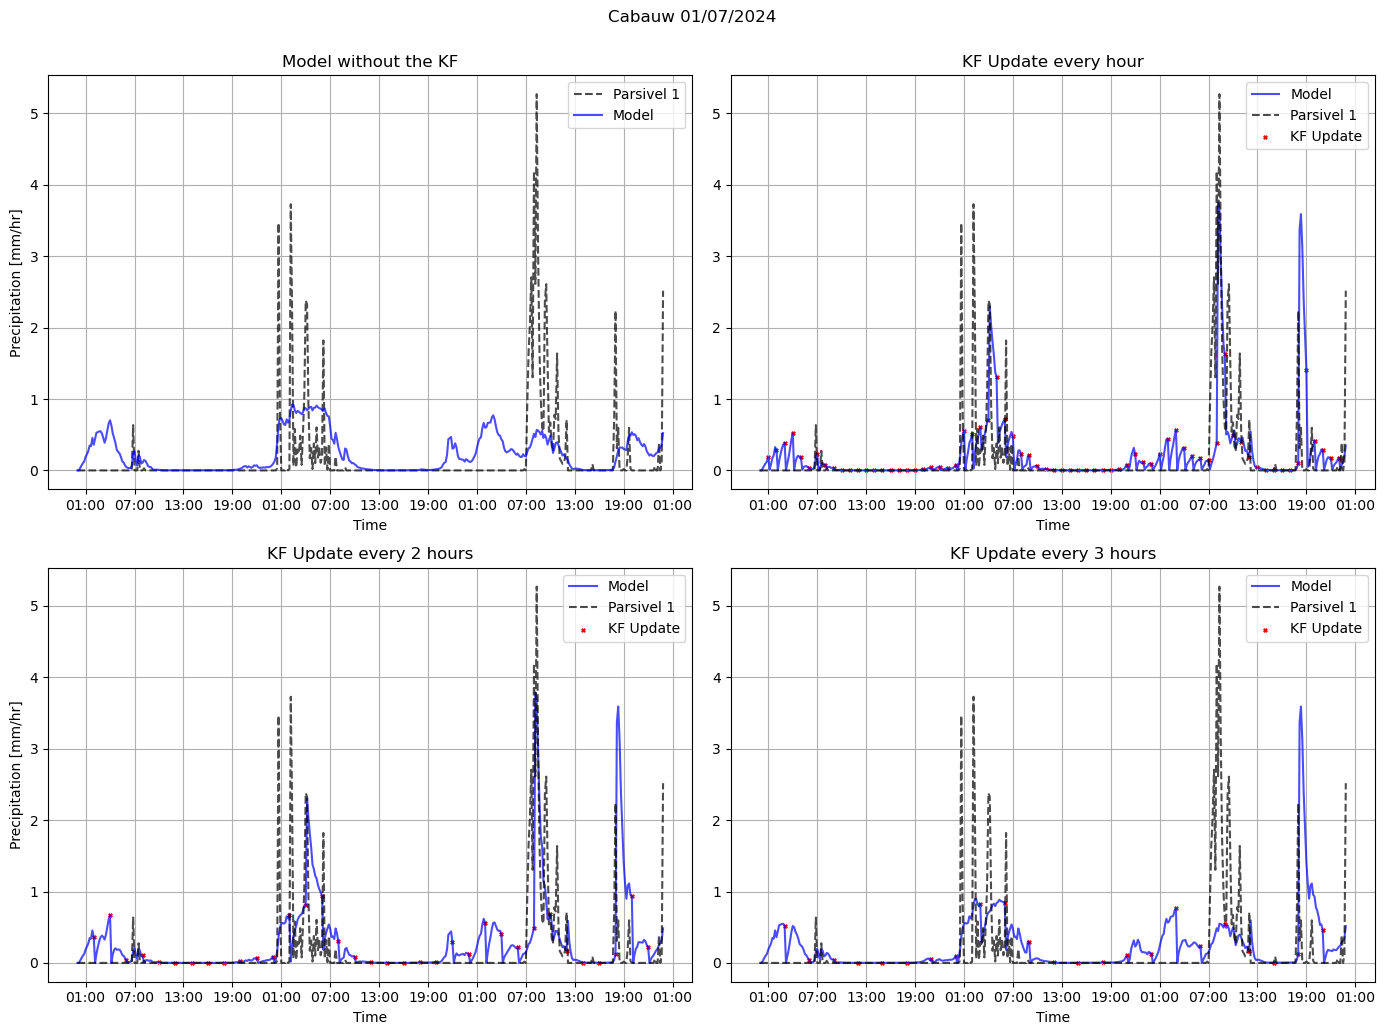

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
# Create a 2x2 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10)) 

# Example time series data (assuming these are already defined)
# measurements_used, rain_rate, P, P_1, P_2, P_3 need to be defined earlier in your code
#t_step = np.linspace(0, len(P), len(P))

#slice_tuple_2 = ('2024-07-01 00:00:00', '2024-07-01 10:59:00')

#indexes = measurements_used.sel(time=slice(*slice_tuple_2)).time
#index_positions = [measurements_used.get_index("time").get_loc(t) for t in indexes.values]

# Define the time slice for the plot
#time_slice = measurements_used.time.sel(time=slice(*slice_tuple_2))

# Panel 1 - Plot model vs observed (rain rate)
axs[0, 0].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[0, 0].plot(time, P* 3600, label='Model', color='blue', alpha=0.7)

axs[0, 0].set_title('Model without the KF')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Precipitation [mm/hr]')
axs[0, 0].legend()
axs[0, 0].grid()

# Panel 4 - Scatter plot (KF Update)
axs[0, 1].plot(time, P_1 * 3600, label='Model', color='blue', alpha=0.7)
axs[0, 1].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[0, 1].scatter(time[kalman_indices_1::kalman_indices_1], P_1[kalman_indices_1::kalman_indices_1]* 3600, label='KF Update', marker='x', s=6, color='red')
axs[0, 1].set_title('KF Update every hour')
axs[0, 1].set_xlabel('Time')
#axs[0, 1].set_ylabel('Precipitation [mm/hr]')
axs[0, 1].legend()
axs[0, 1].grid()


# Panel 3 - Plot Model P_3
axs[1, 0].plot(time, P_2 * 3600, label='Model', color='blue', alpha=0.7)
axs[1, 0].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[1, 0].scatter(time[kalman_indices_2::kalman_indices_2], P_2[kalman_indices_2::kalman_indices_2]* 3600, label='KF Update', marker='x', s=6, color='red')
axs[1, 0].set_title('KF Update every 2 hours')
#axs[1, 0].set_title('Model P_3')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Precipitation [mm/hr]')
axs[1, 0].legend()
axs[1, 0].grid()

# Panel 3 - Plot Model P_3
axs[1, 1].plot(time, P_3 * 3600, label='Model', color='blue', alpha=0.7)
axs[1, 1].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[1, 1].scatter(time[kalman_indices_3::kalman_indices_3], P_3[kalman_indices_3::kalman_indices_3]* 3600, label='KF Update', marker='x', s=6, color='red')
axs[1, 1].set_title('KF Update every 3 hours')
#axs[1, 0].set_title('Model P_3')
axs[1, 1].set_xlabel('Time')
#axs[1, 1].set_ylabel('Precipitation [mm/hr]')
axs[1, 1].legend()
axs[1, 1].grid()
for ax in axs.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Only display hour and minute
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Set locator to show each hour (or adjust as needed)

# Adjust the layout and make sure everything fits well
plt.tight_layout()
plt.suptitle('Cabauw 01/07/2024 ', y=1.03)

# Show the plot
plt.show()
